# Caso de regresión sobre tarífas de Uber

# Fase 1 EDA
## 1. El repositorio de datos contiene un Dataset con un volumen importante de transacciones de viajes y cuya meta es, basado en esta información histórica, generar estimaciones precisas de tarifas.

In [746]:
# Bloque de importaciones generales:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [710]:
# Algunas pre-configuraciones generales para estas librerías
np.random.seed(42) # para que los resultados sean reproducibles
plt.rc('font', family='serif', size=12) # Cambiemos la fuente de las gráficas de matplotlib:

In [711]:
## 2. Importación y Exploración inicial del dataset

In [712]:
# Importación del dataset de Uber
df = pd.read_csv('../data/uber.csv')
print(f"Df shape: {df.shape}")
df.head(20)

Df shape: (200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
5,44470845,27:09.0,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1
6,48725865,04:00.0,24.5,2014-10-12 07:04:00 UTC,-73.961447,40.693965,-73.871195,40.774297,5
7,44195482,52:00.0,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1
8,15822268,32:00.0,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1
9,50611056,06:00.0,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,40.775012,1


In [713]:

df.tail(10)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199990,9577367,05:56.0,12.0,2015-05-24 22:05:56 UTC,-73.987106,40.741894,-73.952240,40.772957,1
199991,13512837,49:14.0,17.5,2015-06-08 10:49:14 UTC,-73.981453,40.743919,-74.013908,40.712635,1
199992,20566507,24:00.0,8.9,2010-01-30 16:24:00 UTC,-74.003548,40.714045,-73.991053,40.684500,1
199993,28359558,51:27.0,9.5,2012-09-29 19:51:27 UTC,-73.987798,40.721210,-73.980960,40.744388,1
199994,3189201,42:00.0,12.0,2014-01-31 14:42:00 UTC,-73.983070,40.760770,-73.972972,40.754177,1
199995,42598914,49:00.0,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,09:00.0,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,42:00.0,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,56:25.0,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695416,1
199999,11951496,08:00.0,14.1,2010-05-15 04:08:00 UTC,-73.984395,40.720077,-73.985508,40.768793,1


In [714]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


**Diccionario de datos del dataset**

Cada fila corresponde a una transacción de viaje de finalizado

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Unnamed: 0` | int | Índice/ID de fila vestigio del CSV original |
| `key` | string/datetime | Identificador único del viaje |
| `fare_amount` | float | Tarifa cobrada por el viaje en USD **(target)**|
| `pickup_datetime` | datetime | Fecha y hora de inicio del viaje (UTC) |
| `pickup_longitude` | float | Longitud del punto de recogida |
| `pickup_latitude` | float | Latitud del punto de recogida |
| `dropoff_longitude` | float | Longitud del punto de destino |
| `dropoff_latitude` | float | Latitud del punto de destino |
| `passenger_count` | int | Número de pasajeros en el viaje |

In [715]:
# Ajuste de tipo de dato sobre la columna pickup_datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [716]:
# Eliminación de columnas recién identificadas que no aportan información relevante para el modelo de predicción:
df = df.drop(columns=['Unnamed: 0', 'key'])

In [717]:
# En cuando a la información de la columa datetime, conviene para este caso tener separada la data de horas e incluso descompuesta la info de fechas, por lo que se crean nuevas columnas con esta información:
# 2. Extracción de features temporales (también determinística)
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # 0=lunes, 6=domingo
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)

# 3. La columna original ya no se necesita para el modelado ya que la info la tenemos en las nuevas columnas y un datetime es mpas dificil de manejar para un modelo de ML, por lo que se elimina:
df = df.drop(columns=['pickup_datetime'])

df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_dayofweek,pickup_hour,is_weekend
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,3,19,0
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,4,20,0
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,0,21,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,4,8,0
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,3,17,0


**Diccionario de datos para los nuevos features desprendidos del datetime**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `pickup_year` | int | Año de inicio del viaje (2009-2015 en este dataset); relevante porque las tarifas cambian con el tiempo (inflación, ajustes de tarifa base) |
| `pickup_month` | int | Mes de inicio del viaje (1-12); captura estacionalidad |
| `pickup_hour` | int | Hora del día de inicio del viaje (0-23); captura patrones de hora pico/valle |
| `pickup_dayofweek` | int (categórico) | Día de la semana de inicio del viaje (0=lunes, 6=domingo); sin orden numérico real, candidato a One-Hot Encoding en el punto 9 |
| `is_weekend` | int (binario) | 1 si el viaje ocurrió sábado o domingo, 0 en caso contrario |

### Expansión de coordenadas: distancia del viaje

Las coordenadas de recogida y destino por separado no son buenas predictoras de `fare_amount`. Juntas si lo son ya que nos habilitan un concepto más claro de describir que es la distancia.

In [718]:
# Función para calcular la distancia entre dos puntos geográficos usando la fórmula de Haversine
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df['trip_distance_km'] = haversine_km(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
# Un vistazo corto para visualizar correlación
df[['fare_amount', 'trip_distance_km']].head()

,fare_amount,trip_distance_km
0,7.5,1.683323
1,7.7,2.457590
2,12.9,5.036377
3,5.3,1.661683
4,16.0,4.475450


**Diccionario de datos — feature nueva desprendida de pickup_long/lat y dropoff_lat/long**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `trip_distance_km` | float | Distancia en línea recta (Haversine) entre el punto de recogida y el de destino, en kilómetros |

**Nota importante:** Para este caso no se eliminan las features asociadas a coordenadas (pickup_*) con las que se calculó la distancia ya que los modelos si se pueden beneficiar de esa información "no consolidada". 

Caso contrario con la feature pickup_datetime en la cual se eliminó ya que esa información "consolidada" no era tan útil para el modelo en ese formato como si lo es la información que se desprendió de ella.

## 3. Análisis estadistico para variables numéricas

In [719]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_dayofweek,pickup_hour,is_weekend,trip_distance_km
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,199999.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535,2011.742440,6.281795,3.048425,13.491335,0.283460,20.855350
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997,1.856397,3.438925,1.946946,6.515531,0.450679,382.964642
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,1.000000,9.000000,0.000000,1.215222
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,3.000000,14.000000,0.000000,2.120992
75%,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000,2013.000000,9.000000,5.000000,19.000000,1.000000,3.875169
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000,2015.000000,12.000000,6.000000,23.000000,1.000000,16409.239135


### 3.1: Análisis sobre fare_amount:
- min: -52 -> Valor negativo sobre la tarifa no tiene sentido lógico. Podría ser un error o un reembolso. Pero en este contexto de predicción no tiene sentido. Se eliminará.
- mean: ~11.35 -> Valor promedio de la tarifa.
- max: 499 -> Valor muy alto sobre la tarifa (comparados con la media y los cuartiles) Podría ser un error o un caso extremo. Candidato a análisis de outliers.

### 3.2 Análisis sobre passenger_count:
- min: 0 -> Valor de pasajeros 0 no tiene sentido lógico. Podría ser un caso de shipping o un error. Se eliminará.
- max: 208 -> Valor imposible en un vehículo. Seguro es un error. Candidato a análisis de outliers.

### 3.3 Análisis sobre pickup_longitude/dropoff_longitude: 
`Los valores válidos para la latitud están entre -90.0° y 90.0°, y para la longitud están entre -180.0° y 180.0°`
- pickup_longitude min: -1340.65 -> Valor fuera de rango. Seguro es un error. Candidato a análisis de outliers.
- dropoff_longitude min: -3356.666300 -> Valor fuera de rango. Seguro es un error. Candidato a análisis de outliers.

### 3.4 Eliminación de valores imposibles y preparación para tratamiento de Outliers

Los casos anteriores (`fare_amount < 0`, `passenger_count = 0` o `208`, coordenadas fuera de `[-90,90]`/`[-180,180]`) no son *outliers* en el sentido estadístico: son valores que violan una restricción física/de negocio fija, sin importar la distribución de los datos. Por eso la decisión es de tratarlos aquí, sobre el dataset completo

In [720]:
# 1. Descartar Filas con fare_ammount (target) inválido: 
# Criterio: se asume poco confiable la data del resto de la fila.
print(f"Filas con target inválido: {df[df['fare_amount'] < 0].shape[0]}")
df = df[df['fare_amount'] >= 0]
print(f"Nuevo shape del df: {df.shape}")

# 2. Tratar Filas con passenger_count inválido:
# Criterio: Aunque este feature tenga valores fuera de rango, el resto de la fila puede ser útil para el modelo. 
# Se reemplaza valor imposible por NaN en lugar de imputarlo directamente en esta fase para no sesgar el modelo.
print(f"Filas con passenger_count inválido: {df[~df['passenger_count'].between(1, 6)].shape[0]}")
df.loc[~df['passenger_count'].between(1, 6), 'passenger_count'] = np.nan

# 3. Tratar Filas con pickup_longitude/dropoff_longitude fuera de rango:
# Mismo criterio que en el caso de passenger_count, se reemplaza valor imposible por NaN en lugar de imputarlo directamente en esta fase para no sesgar el modelo.
# Más adelante en los pipelines se correrá la imputación, estos null se van a reemplazar por la media o mediana
print(f"Filas con pickup_longitude fuera de rango: {df[~df['pickup_longitude'].between(-180, 180)].shape[0]}")
df.loc[~df['pickup_longitude'].between(-180, 180), 'pickup_longitude'] = np.nan
print(f"Filas con dropoff_longitude fuera de rango: {df[~df['dropoff_longitude'].between(-180, 180)].shape[0]}")
df.loc[~df['dropoff_longitude'].between(-180, 180), 'dropoff_longitude'] = np.nan
print(f"Filas con pickup_latitude fuera de rango: {df[~df['pickup_latitude'].between(-90, 90)].shape[0]}")
df.loc[~df['pickup_latitude'].between(-90, 90), 'pickup_latitude'] = np.nan
print(f"Filas con dropoff_latitude fuera de rango: {df[~df['dropoff_latitude'].between(-90, 90)].shape[0]}")
df.loc[~df['dropoff_latitude'].between(-90, 90), 'dropoff_latitude'] = np.nan

# Tratamiento a caso particular para coordenadas del tipo ~(0,0) queson válidas pero no son realistas para este dataset
coord_cero = (
    ((df['pickup_latitude'].abs() < 1) & (df['pickup_longitude'].abs() < 1))
    | ((df['dropoff_latitude'].abs() < 1) & (df['dropoff_longitude'].abs() < 1))
)
print(f"Filas con coordenadas ~(0,0) [Null Island]: {coord_cero.sum()}")
df.loc[coord_cero, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']] = np.nan

# Dado que estas variables se utilizaron para calcular la distancia, se recalcula la distancia:
df['trip_distance_km'] = haversine_km(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

Filas con target inválido: 17
Nuevo shape del df: (199983, 12)
Filas con passenger_count inválido: 710
Filas con pickup_longitude fuera de rango: 7
Filas con dropoff_longitude fuera de rango: 4
Filas con pickup_latitude fuera de rango: 4
Filas con dropoff_latitude fuera de rango: 4
Filas con coordenadas ~(0,0) [Null Island]: 3969


## 4. Identificación de Nulos.
Desde el df.info() inicial identificamos que el dataset original en dropoff_longitude y el dropoff_latitude tienen datos nulos.

In [721]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje (%)': porcentaje_nulos.round(4)
}).sort_values('porcentaje (%)', ascending=False)

resumen_nulos

,nulos,porcentaje (%)
trip_distance_km,3982,1.9912
pickup_longitude,3976,1.9882
dropoff_longitude,3973,1.9867
pickup_latitude,3973,1.9867
dropoff_latitude,3973,1.9867
passenger_count,710,0.3550
fare_amount,0,0.0000
pickup_year,0,0.0000
pickup_month,0,0.0000
pickup_dayofweek,0,0.0000


In [722]:

print(f"Media: {df['passenger_count'].mean()}")
print(f"Mediana: {df['passenger_count'].median()}")
print(f"Moda: {df['passenger_count'].mode()[0]}")

Media: 1.689451154948237
Mediana: 1.0
Moda: 1.0


1. passenger_count (int): Comparado con el df.info inicial sabemos que los nulos fueron introducidos por la limpieza del paso 3.4, Conviene mantener la fila imputandola con la moda al tratarse del valor más frecuente (y entero ya que la media nos arroja un valor que no es plausible en la realidad).

2. pickup_longitude, pickup_latitude, dropoff_longitude, pickup_latitude (float): Dado el bajo volumen de nulos y que su significado es quien indica ubicaciones de los viajes no tiene sentido 'interpolarlos' con datos de otros viajes. Adicional, la eliminación de estos tambien resuelve Tratamiento: Eliminar

In [723]:
# passenger_count se deja con NaN a propósito: se imputará con la moda dentro del pipeline (Fase 2),
# Solo se eliminan filas con nulos en las coordenadas (no se puede "inventar" una ubicación real).
coordenadas = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
df.dropna(subset=coordenadas, inplace=True)
print(df.shape)
print(df.isnull().sum())

(196001, 12)
fare_amount            0
pickup_longitude       0
pickup_latitude        0
dropoff_longitude      0
dropoff_latitude       0
passenger_count      687
pickup_year            0
pickup_month           0
pickup_dayofweek       0
pickup_hour            0
is_weekend             0
trip_distance_km       0
dtype: int64


## 5. Tratamiento de duplicados

In [724]:
rows_inicial = df.shape[0]
print(f"Filas iniciales: {rows_inicial}")

duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

df = df.drop_duplicates()
rows_final = df.shape[0]
print(f"Filas finales: {rows_final}")
print(f"Filas eliminadas: {rows_inicial - rows_final}")


Filas iniciales: 196001
Filas duplicadas: 0
Filas finales: 196001
Filas eliminadas: 0


In [725]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_dayofweek,pickup_hour,is_weekend,trip_distance_km
count,196001.000000,196001.000000,196001.000000,196001.000000,196001.000000,195314.000000,196001.000000,196001.000000,196001.000000,196001.000000,196001.000000,196001.000000
mean,11.345244,-73.907164,40.690438,-73.906623,40.690060,1.690058,2011.739654,6.282417,3.048500,13.490788,0.283519,4.837480
std,9.796100,2.730099,2.623049,2.720523,2.626767,1.306052,1.858800,3.439871,1.947029,6.514365,0.450707,90.428453
min,0.000000,-93.824668,-74.015515,-75.458979,-74.015750,1.000000,2009.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992268,40.736400,-73.991592,40.735277,1.000000,2010.000000,3.000000,1.000000,9.000000,0.000000,1.255854
50%,8.500000,-73.982101,40.753288,-73.980521,40.753727,1.000000,2012.000000,6.000000,3.000000,14.000000,0.000000,2.156936
75%,12.500000,-73.968318,40.767542,-73.965318,40.768327,2.000000,2013.000000,9.000000,5.000000,19.000000,1.000000,3.910557
max,499.000000,40.808425,48.018760,40.831932,45.031598,6.000000,2015.000000,12.000000,6.000000,23.000000,1.000000,6037.956294


## 6. Inconsistencias en variables categoricas.
No aplica. En la caracterización del diccionario de datos no se identificaron variables categoricas (en string).

## 7. Análisis y tratamiento de Outliers implementando IQR

In [726]:
def limites_iqr(serie, k=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lt_fare_amount, ht_fare_amount = limites_iqr(df['fare_amount'], k=1.5)
outliers_fare = df[(df['fare_amount'] < lt_fare_amount) | (df['fare_amount'] > ht_fare_amount)]
print(f"{'fare_amount'}: límites=({lt_fare_amount:.2f}, {ht_fare_amount:.2f}) | Cantidad identificada de outliers={len(outliers_fare)} ({len(outliers_fare)/len(df)*100:.2f}%)")

lt_trip_distance_km, ht_trip_distance_km = limites_iqr(df['trip_distance_km'], k=1.5)
outliers_distance = df[(df['trip_distance_km'] < lt_trip_distance_km) | (df['trip_distance_km'] > ht_trip_distance_km)]
print(f"{'trip_distance_km'}: límites=({lt_trip_distance_km:.2f}, {ht_trip_distance_km:.2f}) | Cantidad identificada de outliers={len(outliers_distance)} ({len(outliers_distance)/len(df)*100:.2f}%)")


fare_amount: límites=(-3.75, 22.25) | Cantidad identificada de outliers=16771 (8.56%)
trip_distance_km: límites=(-2.73, 7.89) | Cantidad identificada de outliers=16281 (8.31%)


Dado que estos limites están arrojando rangos relativamente bajos respecto a los escenarios que se pueden dar en el negocio, y tambien considerando que 'fare_amount' y 'trip_distance_km' son features que por definición son positivos, se opta por recalcularlos, aplicando un tratamiento logaritmico sobre estos features.

In [727]:
lt_fare_amount, ht_fare_amount = limites_iqr( np.log1p(df['fare_amount']), k=1.5 )
lt_fare_amount = np.expm1(lt_fare_amount)
ht_fare_amount = np.expm1(ht_fare_amount)
outliers_fare = df[(df['fare_amount'] < lt_fare_amount) | (df['fare_amount'] > ht_fare_amount)]

print(f"{'fare_amount'}: límites=({lt_fare_amount:.2f}, {ht_fare_amount:.2f}) | Cantidad identificada de outliers={len(outliers_fare)} ({len(outliers_fare)/len(df)*100:.2f}%)")

lt_trip_distance_km, ht_trip_distance_km = limites_iqr( np.log1p(df['trip_distance_km']), k=1.5 )
lt_trip_distance_km = np.expm1(lt_trip_distance_km)
ht_trip_distance_km = np.expm1(ht_trip_distance_km)
outliers_distance = df[(df['trip_distance_km'] < lt_trip_distance_km) | (df['trip_distance_km'] > ht_trip_distance_km)]
print(f"{'trip_distance_km'}: límites=({lt_trip_distance_km:.2f}, {ht_trip_distance_km:.2f}) | Cantidad identificada de outliers={len(outliers_distance)} ({len(outliers_distance)/len(df)*100:.2f}%)")


fare_amount: límites=(1.61, 35.16) | Cantidad identificada de outliers=7159 (3.65%)
trip_distance_km: límites=(-0.30, 14.77) | Cantidad identificada de outliers=4877 (2.49%)


### Análisis IQR

El criterio IQR para este caso ayuda a identificar los casos 'comunes' que se llevan a cabo en el negocio. Sin embargo, los límites entre tarífas y distancias sugeridos, excluirían unos escenarios de negocio plausibles como traslados a aeropuertos lejanos o entre ciudades que son uno de los casos de uso de este modelo. 

Dados los limites, relativamente bajos que está dando este criterio comparado con los valores máximos presentes en el dataset para estos features, podría interpretarse como un dataset desbalanceado en cuanto a viajes de largo trayecto / alto costo. 

Antes de tomar una decisión 100% basada en este criterio voy a observar la distribución de los datos

**Recomendación Basado en el criterio IQR**: Eliminar aquellas filas identificadas cómo Outliers. El bajo volumen de estos casos (largas distancias), aunque plausibles como caso de negocio pueden no ser un volumen significante para entrenar adecuadamente un modelo que genere estimaciones para trayectos cortos y largos al tiempo. Inclusive, conservarlos pordría tener un impacto negativo en la estimación de casos generales que correspondan a viajes de cortas distancias.

Nota: Dado que hay valores de trip_distance y fare_amount altos aún después de la limpieza. Conviene analizarlo más a profundidad, por ejemplo agrupando estos valores para identificar si corresponden a situaciones particulares como viajes de larga distancia genuinos para asegurar que no son datos mal digitados que sobrevivieron a toda la limpieza previa.

### Análisis gráfico complementario
Se plantea un scatter plot para analizar el comportamiento del costo vs la distancia

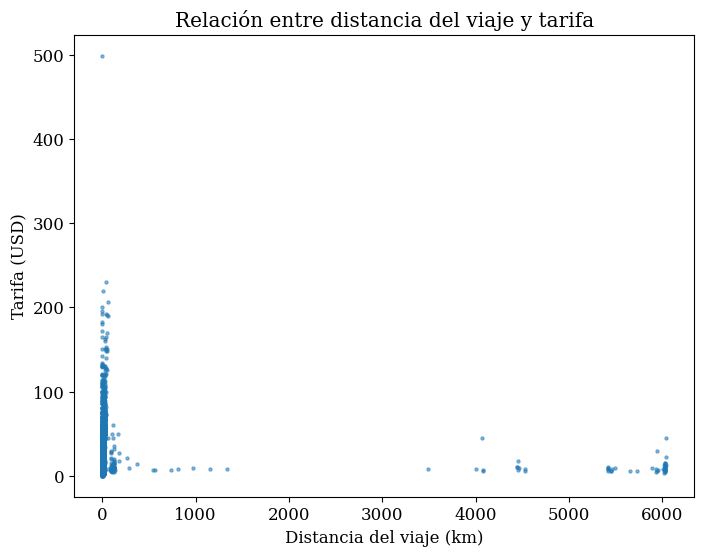

In [728]:
plt.figure(figsize=(8, 6))
plt.scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.5, s=5)
plt.xlabel('Distancia del viaje (km)')
plt.ylabel('Tarifa (USD)')
plt.title('Relación entre distancia del viaje y tarifa')
plt.show()

Análisis del scatter Distancia vs tarífa: 
- Visualmente se detectan un aparente outlier en la tarifa (~500USD) muy alejado de la concentración de datos.
- Visualmente se identifica una anormalidad los costos para viajes de largas distancias. Por lógica de negocio se esperaría que esos viajes tuvieran un costo directamente alto. Pero se evidencia que todos están debajo del rango de los 100USD lo cual no tiene sentido si se tiene en cuenta la lógica de operación del negocio.  

In [729]:
## Aplicación de criterio IQR para eliminar outliers en fare_amount y trip_distance_km
df = df[(df['fare_amount'] >= lt_fare_amount) & (df['fare_amount'] <= ht_fare_amount)]
df = df[(df['trip_distance_km'] >= lt_trip_distance_km) & (df['trip_distance_km'] <= ht_trip_distance_km)]
print(f"Nuevo shape del df después de eliminar outliers en criterio IQR: {df.shape}")

Nuevo shape del df después de eliminar outliers en criterio IQR: (188231, 12)


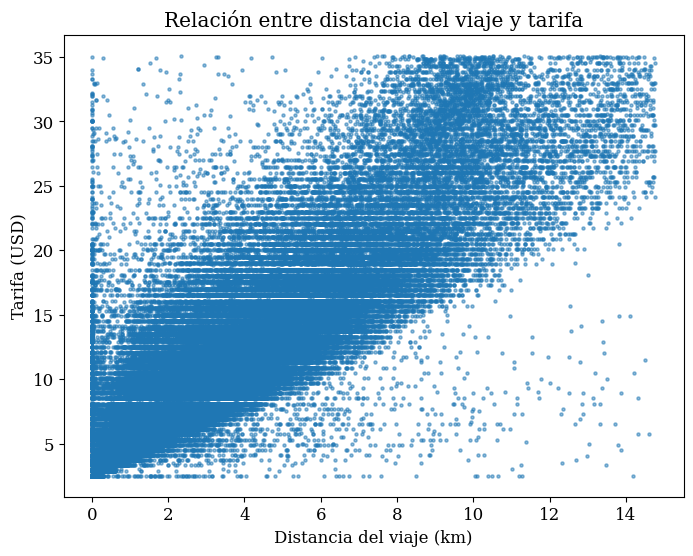

In [730]:
plt.figure(figsize=(8, 6))
plt.scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.5, s=5)
plt.xlabel('Distancia del viaje (km)')
plt.ylabel('Tarifa (USD)')
plt.title('Relación entre distancia del viaje y tarifa')
plt.show()

Posterior a la aplicación del criterio IQR se visualiza una correlación más clara entre tarifa y distancia. Aunque la tendencia es visible para su interpretación y uso predictivo aún falta la inclusión de criterios como horarios y dias pico. Pero para este punto se da por obtenido lo buscado para esta etapa: un dataset sustancialmente más limpio.


## 8. Graficas de EDA


Text(0.5, 1.0, 'Distribución de la tarifa (fare_amount)')

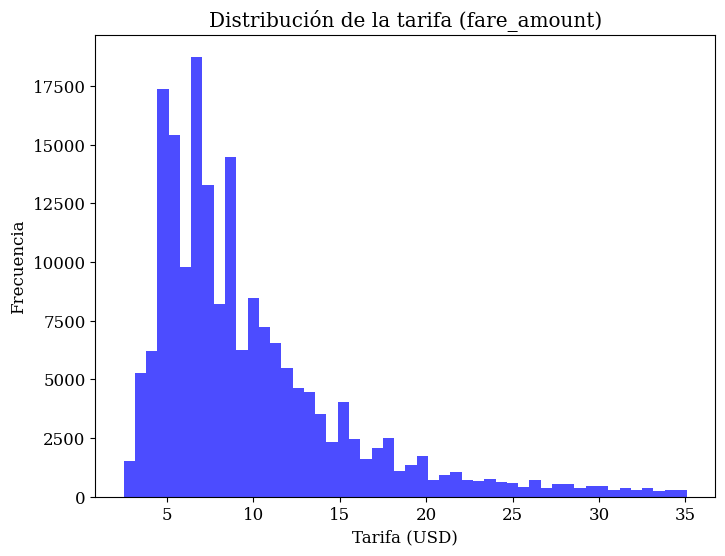

In [731]:
plt.figure(figsize=(8, 6))
plt.hist(df['fare_amount'], bins=50, color='blue', alpha=0.7)
plt.xlabel('Tarifa (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución de la tarifa (fare_amount)')

Tarifas sesgadas a la derecha y altamente contentradas en el rango entre 5 y 10USD. Al tener mayor volumen datos en ese rango, las predicciones que resulten en esos valores seguro tendrán mayor rango de precisión.

Text(0.5, 1.0, 'Cantidad de viajes por hora del día')

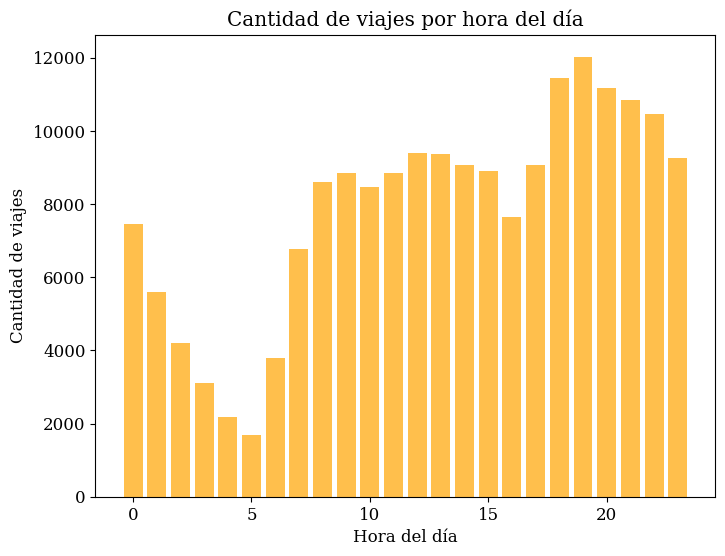

In [732]:
plt.figure(figsize=(8, 6))
plt.bar(df['pickup_hour'].value_counts().sort_index().index, df['pickup_hour'].value_counts().sort_index().values, color='orange', alpha=0.7)
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de viajes')
plt.title('Cantidad de viajes por hora del día')

Diagrama de barras mostrando las tendencias en la solicitud de viajes de acuerdo con la hora del día. Importante para el modelo predictivo ya que en el modelo de negocio existe el concepto de tarifa dinámica, en el cual dependiendo de la demanda se ajustan las tarífas.

Text(0.5, 1.0, 'Distribución de viajes por día de la semana')

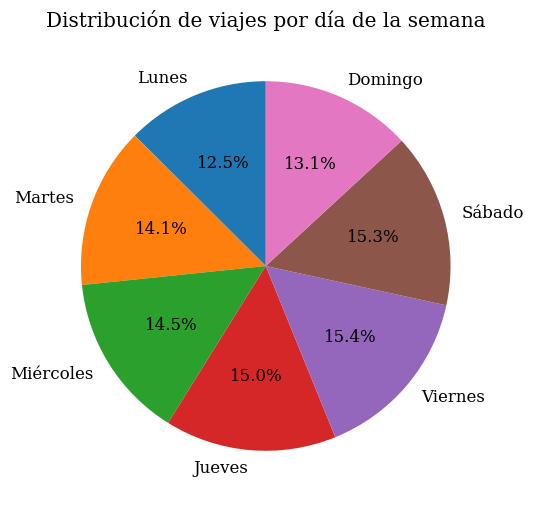

In [733]:
plt.figure(figsize=(8, 6))
plt.pie(df['pickup_dayofweek'].value_counts().sort_index().values, labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'], autopct='%1.1f%%', startangle=90)
plt.title('Distribución de viajes por día de la semana')

Aproximadamente distribuida equitativamente entre los días de la semana. Quedaría pendiente de evaluar combinaciones que consideren el día y la hora.

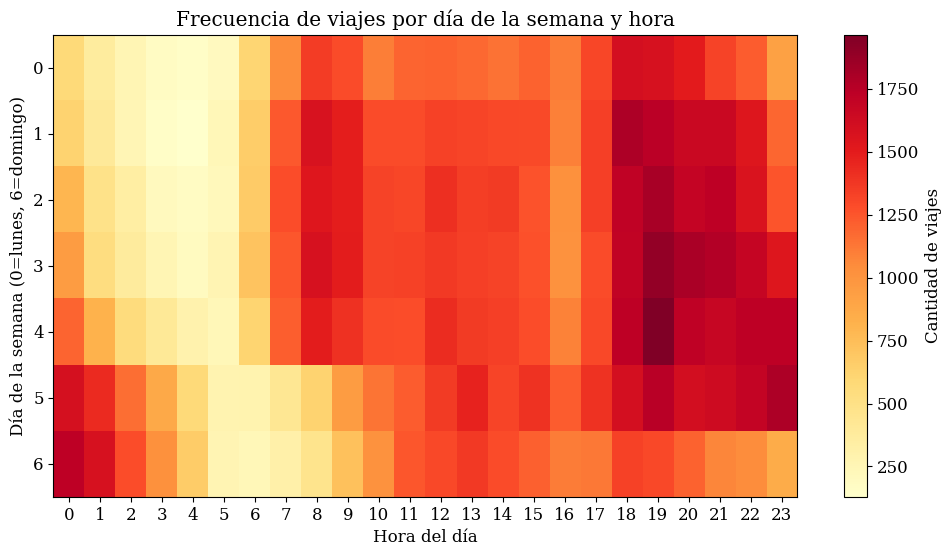

In [734]:
tabla = df.groupby(['pickup_dayofweek', 'pickup_hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.imshow(tabla, aspect='auto', cmap='YlOrRd')
plt.colorbar(label='Cantidad de viajes')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana (0=lunes, 6=domingo)')
plt.xticks(range(24), range(24))
plt.yticks(range(7), range(7))
plt.title('Frecuencia de viajes por día de la semana y hora')
plt.show()


Gráfico permite identificar las franjas horarias de mayor demanda según el día de la semana. Por ejemplo permite notar una concentración de viajes en las primeras horas de los fines de semana, incluso notandose desde los jueves, además de un pico de demanda los viernes a las 7pm.

## 9. Encoding para variables categoricas
Variables categoricas del dataset:
- pickup_month: Feature nominal y ciclica, cadinalidad 12.
- pickup_dayofweek: Feature nominal y ciclica, cadinalidad 7.
- pickup_hour: Feature nominal y ciclica, cadinalidad 24.
- is_weekend: binaria, ya precodificada

**Decisión Aplicar One-Hot Encoding a pickup_month, pickup_dayofweek y pickup_hour**

Adicional, si bien is_weekend ya tiene su encoding binario, es una variable que puede derivarse del pickup_dayofweek, por lo que la decisión aquí para simplificar el modelo es eliminarla.

Nota: Debido a la naturaleza ciclica, y a la cardinalidad relativamente alta respecto al tamaño del dataset, podría adoptarse una alternativa más óptima de encoding que no genere tantas nuevas columnas y que además conserve la "adyacencia circular" de las variables ciclicas cómo por ejemplo un método que ayude a proyectar la hora sobre un círculo (seno/coseno).

In [735]:
df = df.drop(columns=['is_weekend'])

## 10. Escalamiento de Features numéricos
Dado que los distintos features del dataset tienen ordenes de magnitud de diferencia (por ejemplo, distancias en decenas, vs años en miles), se determina es necesario escalado.

Elección del Scaler: Dado que los modelos a entrenar son sensibles a la escala y que las técnicas StandardScaler y MinMaxScaler tienen sensibilidad a Outliers, la decisión aquí es escalar las variables numéricas utilizando RobustScaler.

# Fase 2 - División de datos y Pipelines

## 11. División de los datos en conjuntos de train/validation y test (70/15/15)


In [736]:
# Separación de features (X) y target (y) antes del split.
# fare_amount nunca debe estar en X: es la variable que el modelo debe predecir.
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

In [737]:
# PASO 1: Separar el Test set (15% del total)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# PASO 2: Separar el Validation set del bloque temporal
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

## 12 Generación de Pipelines por Dataset

In [738]:
# --- 1. Numéricas continuas: imputar + escalar ---

numeric_features = ['trip_distance_km', 'passenger_count', 'pickup_year',
                    'pickup_latitude', 'pickup_longitude',
                    'dropoff_latitude', 'dropoff_longitude']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', RobustScaler())
])

# --- 2. Categóricas nominales: One-Hot ---
categorical_features = ['pickup_dayofweek', 'pickup_month', 'pickup_hour']
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# --- Combinación en un solo preprocesador (general para los 3 conjuntos) ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

# --- Ajustar el preprocesador con X_train únicamente ---
preprocessor.fit(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# --- Pipelines individuales por modelo ---
pipeline_ridge = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', Ridge())])
pipeline_lasso = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', Lasso())])
pipeline_knn = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', KNeighborsRegressor())])


## 13. VErificación de Data Leakage
Durante la fase de EDA se tuvo especial cuidado de no ejecutar imputaciones utilizando variables estadisticas para imputar alguno de los features. Dejando dicha imputación pendiente por ejecutarse justo en el paso anterior via los pipelines con los datasets ya aislados sobre los cuales se aplicó unicamente el .fit sobre train y los .transform sobre los otros datasets.

# Fase 3 - Modelado del modelo de regresión

## 14. Entrenamiento de modelos con X_train

In [739]:
pipeline_knn.fit(X_train, y_train)
pipeline_ridge.fit(X_train, y_train)
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['pickup_longitude','pickup_latitude','dropoff_longitude',..., 'pickup_dayofweek','pickup_hour','trip_distance_km']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

## 15. Predicciones sobre los modelos entrenados

In [740]:
pred_ridge_val = pipeline_ridge.predict(X_val)
pred_lasso_val = pipeline_lasso.predict(X_val)
pred_knn_val = pipeline_knn.predict(X_val)

comparacion = pd.DataFrame({
    'real': y_val.values,
    'pred_knn': pred_knn_val,
    'pred_ridge': pred_ridge_val,
    'pred_lasso': pred_lasso_val,
})
comparacion.head(10)


,real,pred_knn,pred_ridge,pred_lasso
0,5.30,5.820,7.344377,7.364832
1,6.10,5.580,6.346445,7.668541
2,21.87,26.428,19.704255,17.684037
3,10.00,9.140,10.585873,10.222029
4,5.50,6.600,5.845505,6.284894
5,10.90,9.620,12.240219,12.917747
6,24.90,20.760,23.904598,20.825820
7,8.50,9.380,9.772329,10.600746
8,4.50,8.580,4.242728,6.745464
9,25.47,28.398,23.932182,20.513509


# Fase 5 - Métricas en train y validación: detección de overfitting/underfitting

## 18. Evaluación de modelos en Train y Val

In [741]:
resultados = []
for nombre, pipeline in [('KNN', pipeline_knn), ('Ridge', pipeline_ridge), ('Lasso', pipeline_lasso)]:
    for conjunto, X_split, y_split in [('train', X_train, y_train), ('val', X_val, y_val)]:
        pred = pipeline.predict(X_split)
        mae = mean_absolute_error(y_split, pred)
        mse = mean_squared_error(y_split, pred)
        r2 = r2_score(y_split, pred)
        resultados.append({'modelo': nombre, 'conjunto': conjunto, 'MAE': mae, 'MSE': mse, 'R2': r2})

tabla_metricas = pd.DataFrame(resultados)
tabla_metricas


,modelo,conjunto,MAE,MSE,R2
0,KNN,train,1.646121,5.653929,0.829220
1,KNN,val,2.004657,8.441618,0.743770
2,Ridge,train,1.802778,7.581343,0.771002
3,Ridge,val,1.801119,7.483022,0.772867
4,Lasso,train,2.147833,9.573355,0.710832
5,Lasso,val,2.140879,9.480611,0.712233


**Interpretación de variables estadisticas:**

*KNN*: 
- Señales de Overfitting con R2 de val inferior al de train y con la mayor diferencia comparado con los r2 de los otros modelos.
- MAE de ~USD1.6 (el mejor en train) a ~USD2 para una mediana de ~USD8.5 sobre la tarifa de viaje representa un margen apmlio en la predicción.
- R2: Explica el ~74% de la varibilidad de las tarifas

*Ridge*:
- R2 muy similares entre train y val. Sin señales de overfitting
- MAE muy similar tambien entre ambos df. El error promedio de ~USD1.8 respecto a la mediana de ~USD8.5 es el consistente más bajo, pero mejorable para un modelo de producción.
- R2: Explica el ~77% de la varibilidad de las tarifas

*Lasso*: 
- R2 muy similares entre train y val. Sin señales de overfitting
- MAE muy similar tambien entre ambos df. El error promedio de ~USD2.14 para una mediana de ~USD8.5 sobre la tarifa de viaje representa un margen apmlio en la predicción.
- R2: Explica el ~71% de la varibilidad de las tarifas


## 20. Tabla comparativa train/ validación

In [742]:
tabla_comparativa_regresion = tabla_metricas.pivot(index='modelo', columns='conjunto', values=['MAE', 'MSE', 'R2'])
tabla_comparativa_regresion.columns = [f'{metrica}_{conjunto}' for metrica, conjunto in tabla_comparativa_regresion.columns]
tabla_comparativa_regresion = tabla_comparativa_regresion[
    ['MAE_train', 'MSE_train', 'R2_train', 'MAE_val', 'MSE_val', 'R2_val']
]
tabla_comparativa_regresion


,MAE_train,MSE_train,R2_train,MAE_val,MSE_val,R2_val
modelo,,,,,,
KNN,1.646121,5.653929,0.829220,2.004657,8.441618,0.743770
Lasso,2.147833,9.573355,0.710832,2.140879,9.480611,0.712233
Ridge,1.802778,7.581343,0.771002,1.801119,7.483022,0.772867


## 21. Mejor modelo para problema de regresión

La métricas comparativas favorecen al modelo Ridge ya que no tiene señales de overfitting y el mejor desempeño.

Comparado con otros modelos como KNN y Lasso, Ridge cuenta con hiperparámetro menos sensibles a cambios. Tambien, el tiempo de predicción de KNN es alto debido a su propia naturaleza de funcionamiento (de busqueda de k vecinos más cercanos) que empeora incluso cuando se aumenta el tamaño del dataset. En este sentido las opciones más rápidas son Ridge y Lasso, pero de acuerdo con la evaluación anterior Ridge es a su vez, más preciso en esta aplicación.  

# Fase 6 - Evaluación de los modelos entrenados con el conjunto de test.

In [743]:
# 22. Evaluación de los modelos sobre el conjunto de test (15% del total) para obtener métricas finales de desempeño.
resultados_test = []
for nombre, pipeline in [('KNN', pipeline_knn), ('Ridge', pipeline_ridge), ('Lasso', pipeline_lasso)]:
    for conjunto, X_split, y_split in [('test', X_test, y_test)]:
        pred = pipeline.predict(X_split)
        mae = mean_absolute_error(y_split, pred)
        mse = mean_squared_error(y_split, pred)
        r2 = r2_score(y_split, pred)
        resultados_test.append({'modelo': nombre, 'conjunto': conjunto, 'MAE': mae, 'MSE': mse, 'R2': r2})

tabla_metricas_test = pd.DataFrame(resultados_test)
tabla_metricas_test

,modelo,conjunto,MAE,MSE,R2
0,KNN,test,2.003570,8.386204,0.744368
1,Ridge,test,1.801108,7.441699,0.773159
2,Lasso,test,2.138632,9.303078,0.716420


In [744]:
# 23. Tabla comparativa de métricas finales de desempeño sobre el conjunto de test (15% del total) para los modelos entrenados.

val_rows = tabla_metricas[tabla_metricas['conjunto'] == 'val']
comparacion_val_test = pd.concat([val_rows, tabla_metricas_test], ignore_index=True)

tabla_comparativa_val_test = comparacion_val_test.pivot(index='modelo', columns='conjunto', values=['MAE', 'MSE', 'R2'])
tabla_comparativa_val_test.columns = [f'{metrica}_{conjunto}' for metrica, conjunto in tabla_comparativa_val_test.columns]
tabla_comparativa_val_test = tabla_comparativa_val_test[
    ['MAE_val', 'MSE_val', 'R2_val', 'MAE_test', 'MSE_test', 'R2_test']
]
tabla_comparativa_val_test

,MAE_val,MSE_val,R2_val,MAE_test,MSE_test,R2_test
modelo,,,,,,
KNN,2.004657,8.441618,0.743770,2.003570,8.386204,0.744368
Lasso,2.140879,9.480611,0.712233,2.138632,9.303078,0.716420
Ridge,1.801119,7.483022,0.772867,1.801108,7.441699,0.773159


**Conclusiones tras evaluación de test**:
- El ranking se mantiene igual tras ejecutar las predicciones en test. Las métricas para los 3 modelos son muy somilares
- Las métricas de Ridge son las que menos variación tienen en esta comparativa. (El más consistente)
- El modelo Ridge mantiene el mayor R2 entre los 3 modelos.

Una variación importante aquí hubiese indicado que el preprocesamiento o las múltiples limpiezas se aplicaron para un grupo específico de valores mayormente ubicado en el de evaluación y que llevaron al modelo a no generalizar correctamente. 

# Fase 7. Cross Validation y optimización de hiperparámetros

## 24. Cross validation en mis palabras:
Esta es un técnica cuyo objetivo es hacer un refinamiento de hiperparámetros, utilizando de manera recursiva los datasets disponibles (excluyendo test).
Funciona haciendo "trains" secuenciales con los datos disponibles para así conseguir una configuración más optima de los hiperparámetros.
Se asocia un mejor desempeño ya que los hiperparámetros se seleccionan de acuerdo con cuales se ajustan consistentemente mejor a diferentes particiones de datos, no solo a aquél de un único split. 

In [747]:
# 25. Ejecutar un cross-validation uniendo X_train y X_val sobre el mejor modelo obtenido (Ridge)

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

pipeline_ridge_search = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', Ridge())
])

# Distribución de hiperparámetros: alpha en escala logarítmica (su efecto es multiplicativo, no lineal)
param_dist = {
    'model__alpha': np.logspace(-3, 3, 50)  # de 0.001 a 1000
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline_ridge_search,
    param_distributions=param_dist,
    n_iter=20,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_full, y_train_full)

print("Mejor alpha encontrado:", random_search.best_params_)
print("Mejor MAE promedio (CV):", -random_search.best_score_)

Mejor alpha encontrado: {'model__alpha': np.float64(59.636233165946365)}
Mejor MAE promedio (CV): 1.803353413050702


In [748]:
# 27. Evaluación del mejor modelo (Ridge con alpha optimizado) sobre el conjunto de test (15% del total) para obtener métricas finales de desempeño.
best_ridge_model = random_search.best_estimator_

pred_ridge_test_opt = best_ridge_model.predict(X_test)

mae_test_opt = mean_absolute_error(y_test, pred_ridge_test_opt)
mse_test_opt = mean_squared_error(y_test, pred_ridge_test_opt)
r2_test_opt = r2_score(y_test, pred_ridge_test_opt)

print(f"Ridge optimizado (alpha={random_search.best_params_['model__alpha']:.4f}) - Test:")
print(f"MAE={mae_test_opt:.4f} | MSE={mse_test_opt:.4f} | R2={r2_test_opt:.4f}")


### Comparación de métricas finales de desempeño entre el mejor modelo optimizado y los modelos iniciales sobre el conjunto de test (15% del total).
mae_original = tabla_metricas_test.loc[tabla_metricas_test['modelo'] == 'Ridge', 'MAE'].values[0]
mse_original = tabla_metricas_test.loc[tabla_metricas_test['modelo'] == 'Ridge', 'MSE'].values[0]
r2_original = tabla_metricas_test.loc[tabla_metricas_test['modelo'] == 'Ridge', 'R2'].values[0]

comparacion_ridge = pd.DataFrame({
    'Ridge original (alpha=1.0)': [mae_original, mse_original, r2_original],
    f"Ridge optimizado (alpha={random_search.best_params_['model__alpha']:.4f})": [mae_test_opt, mse_test_opt, r2_test_opt],
}, index=['MAE', 'MSE', 'R2'])

comparacion_ridge


Ridge optimizado (alpha=59.6362) - Test:
MAE=1.8007 | MSE=7.4418 | R2=0.7732


,Ridge original (alpha=1.0),Ridge optimizado (alpha=59.6362)
MAE,1.801108,1.800712
MSE,7.441699,7.441757
R2,0.773159,0.773157


### Interpretación tras ajuste en cross-vsalidation:
Los parámetros estadisticos indican que la estimación con el modelo optimizado no representa una mejora significativa en términos de precisión en la estimación de la tarifa. Aquí, probablemente lo que se está evidenciando es una relación que no es directamente lineal entre el target y los features, requiriendo modelos de orden mayor para ajustarse mejor al valor real.


# Fase 8. Predicción sobre un viaje inventado.

Descripción del caso: Un viaje de viernes a las 7pm (identificado como pico de demanda), entre 2 sectores concurridos de NY.



In [ ]:
viaje_inventado = pd.DataFrame({
    'passenger_count': [1],
    'pickup_year': [2015],
    'pickup_month': [6],
    'pickup_dayofweek': [4],        # 4 = viernes
    'pickup_hour': [19],            # 7pm, pico de demanda identificado en el heatmap
    'pickup_latitude': [40.8116],   # Harlem, Manhattan
    'pickup_longitude': [-73.9465],
    'dropoff_latitude': [40.7074],  # Wall Street, Manhattan
    'dropoff_longitude': [-74.0113],
})

viaje_inventado['trip_distance_km'] = haversine_km(
    viaje_inventado['pickup_latitude'], viaje_inventado['pickup_longitude'],
    viaje_inventado['dropoff_latitude'], viaje_inventado['dropoff_longitude']
)

prediccion = best_ridge_model.predict(viaje_inventado)
print(f"Distancia calculada: {viaje_inventado['trip_distance_km'].values[0]:.2f} km")
print(f"Tarifa estimada por el modelo: ${prediccion[0]:.2f}")
print("---")

# Comparar esta estimación con viajes reales similares
similares = df[
    (df['trip_distance_km'].between(10, 14)) &
    (df['pickup_hour'].between(17, 21)) &
    (df['pickup_dayofweek'].isin([4, 5]))  # viernes o sábado, hora similar
]
print(f"Viajes reales similares encontrados: {len(similares)}")
print(similares['fare_amount'].describe())



Distancia calculada: 12.81 km
Tarifa estimada por el modelo: $33.76
---
Viajes reales similares encontrados: 172
count    172.000000
mean      27.243430
std        5.225586
min        6.100000
25%       24.975000
50%       27.600000
75%       31.075000
max       35.000000
Name: fare_amount, dtype: float64


Tras comparar la estimación vs los costos de viajes similares se determina que el costo de $33.76 es realista según las tarifas para distancias similares y dado que el viaje dummy se generó en un pico de demanda, se asume como correcto el costo ligeramente elevado.

# 9. Conclusiones

Para este caso de regresión, Ridge fue el mejor modelo (MAE≈$1.80, R²≈0.77, consistente entre train/val/test). Tuvo mejor desempeño comparado con KNN el cuál presento indicios de overfitting y Lasso el cual, a pesar de no mostrar overfitting tuvo el desempeño absoluto.

En cuanto a la limpieza más determinante, fué la aplicada sobre los features que implican coordenadas y que tenían coordenadas corruptas del tipo "Null Island" ~(0,0)" — antes de corregirlo, la correlación entre trip_distance_km y fare_amount era prácticamente nula (0.033); después de la limpieza, subió a 0.86. La creación de trip_distance_km vía Haversine fue, en consecuencia, la feature individual más determinante de todo el pipeline.

En cuando a limitaciones del estudio hay varias:
- El dataset no tiene dropoff_datetime — solo se captura el componente de tarifa por distancia, no por tiempo/tráfico real.
- El filtro de outliers por IQR (punto 7) excluyó viajes de más de ~14.77 km — el modelo no puede predecir con confianza viajes largos genuinos (aeropuertos, intermunicipales)
- trip_distance_km (feature añadido aplicando ingeniería de caracteristicas) es distancia en línea recta, no la distancia real recorrida por calles, lo cual si bien sirve de indicio, no representa fielmente la realidad de los viajes.

Preguntas abiertas:
- ¿Cuánto mejoraría Ridge con features de interacción (Ej.: distancia × hora) vía PolynomialFeatures?

- ¿Un KNN con n_neighbors bien optimizado lograría cerrar la brecha con Ridge?

- ¿Cómo se comportaría un modelo no lineal (fuera del alcance de este taller) frente al techo que Ridge parece haber alcanzado?

- ¿Cómo se habrían comportado los modelos con encoding cíclico (seno/coseno) en vez de One-Hot para pickup_hour? — especialmente relevante para KNN, dado que reduciría la dimensionalidad (2 columnas en vez de 23) y podría mitigar parte del overfitting observado, al preservar la cercanía real entre horas adyacentes que el One-Hot destruye en ese feature.

### Plots más relevantes

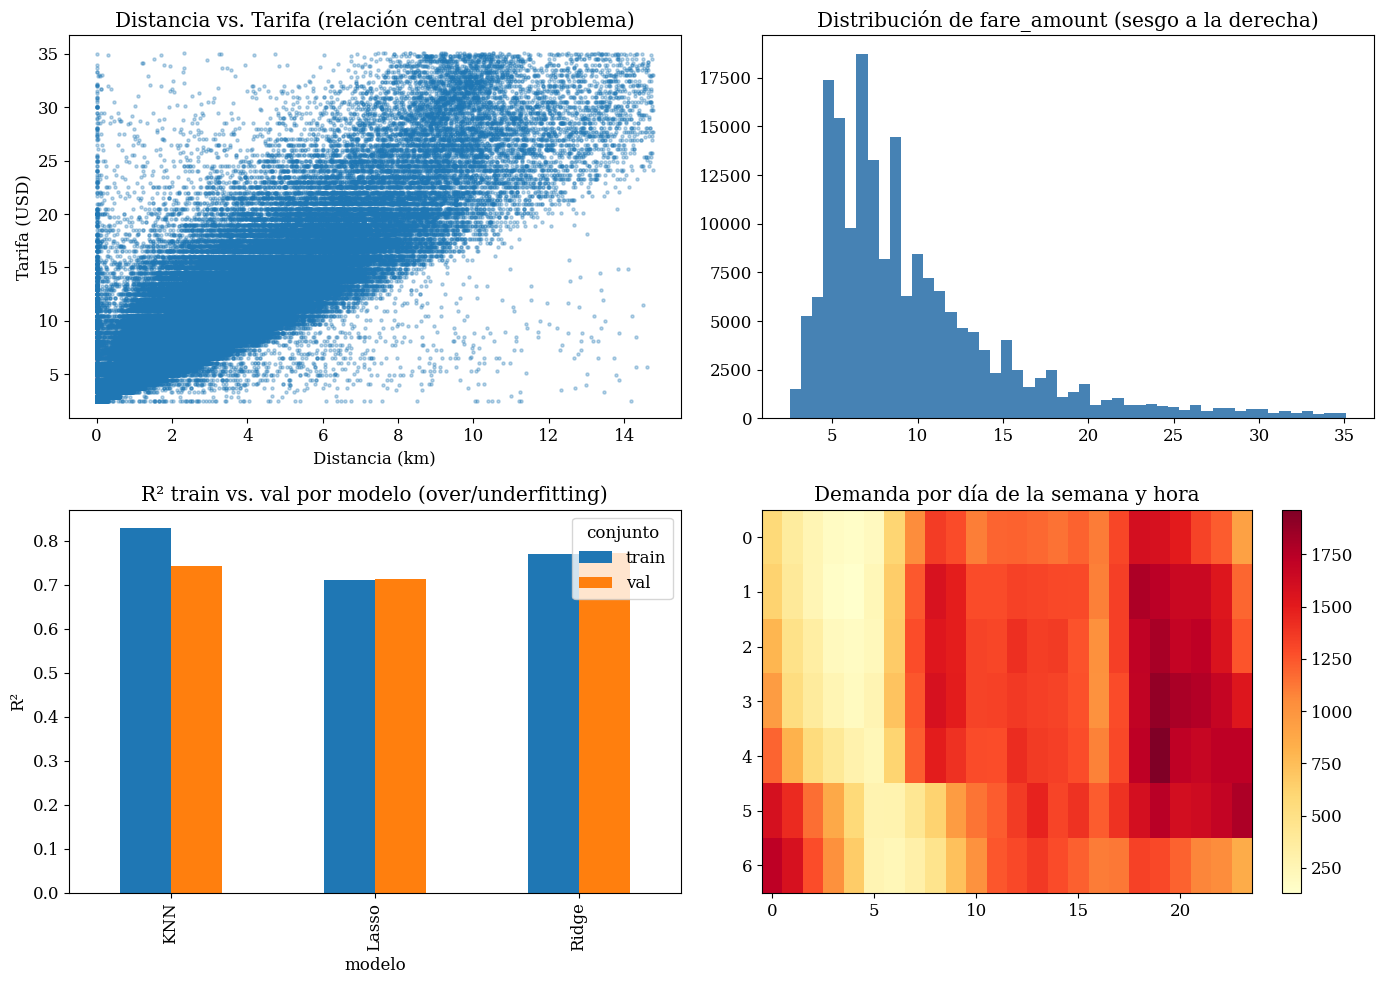

In [752]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.3, s=5)
axes[0,0].set_title('Distancia vs. Tarifa (relación central del problema)')
axes[0,0].set_xlabel('Distancia (km)'); axes[0,0].set_ylabel('Tarifa (USD)')

axes[0,1].hist(df['fare_amount'], bins=50, color='steelblue')
axes[0,1].set_title('Distribución de fare_amount (sesgo a la derecha)')

tabla_pivot = tabla_metricas.pivot(index='modelo', columns='conjunto', values='R2')
tabla_pivot.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('R² train vs. val por modelo (over/underfitting)')
axes[1,0].set_ylabel('R²')

im = axes[1,1].imshow(tabla, aspect='auto', cmap='YlOrRd')
axes[1,1].set_title('Demanda por día de la semana y hora')
fig.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()
